# Excercise 6: 2D Heat Diffusion with Triton

In this tutorial, you will write a fused 2D stencil kernel for heat diffusion that is
significantly faster than PyTorch's built-in operations.

In doing so, you will learn about:

* **2D spatial memory access patterns** -- how GPU threads map to a 2D grid.
* **Stencil computations** -- reading neighbor values from a structured grid.
* **The benefits of kernel fusion** -- combining the Laplacian computation and the update step into a single kernel.
* **The "halo" problem** -- how boundary data must be handled when tiling a stencil.

## The Physics: Heat Equation

We simulate heat diffusing across a 2D metal plate using the **Finite Difference Method**.
The temperature $u$ at grid point $(x, y)$ at the next time step $t+1$ is:

$$u_{x,y}^{t+1} = u_{x,y}^{t} + \alpha \left( u_{x+1,y}^{t} + u_{x-1,y}^{t} + u_{x,y+1}^{t} + u_{x,y-1}^{t} - 4 \, u_{x,y}^{t} \right)$$

This is a **5-point stencil**: each cell reads itself and its 4 immediate neighbors.
The coefficient $\alpha$ controls the diffusion rate (must be $\leq 0.25$ for stability).

### Why is this problem perfect for GPU optimisation?

Every cell can be updated **independently** -- the new value depends only on the *current* time step.
This is embarrassingly parallel and maps perfectly to GPU threads.

### Why is naive PyTorch suboptimal?

A naive PyTorch implementation performs multiple memory round-trips:
1. Compute the Laplacian (read grid, write intermediate)
2. Multiply by $\alpha$ (read intermediate, write intermediate)
3. Add to original grid (read both, write result)

In [1]:
import torch
import torch.nn.functional as F

import triton
import triton.language as tl

DEVICE = triton.runtime.driver.active.get_active_torch_device()
print(f"Using device: {DEVICE}")

Using device: cuda:0


## Implementation 1: Naive PyTorch (Explicit Indexing)

The most straightforward approach uses tensor slicing to gather neighbor values.

* Extract 5 tensors of (H-2, W-2) shape that correspond to: center, up, down, left and right values
* Now thanks to vectorised computations we can calculate each operation for all elements in parallel

The approach is very simple, however each slice is a separate kernel launch and memory round-trip.

In [2]:
def heat_step_naive(u, alpha=0.25):
    """One step of 2D heat diffusion using explicit slicing.
    
    Boundary cells are left unchanged (Dirichlet boundary conditions).
    """
    u_new = u.clone()
    # Interior update: 4 reads + 1 write, each a separate GPU kernel
    u_new[1:-1, 1:-1] = u[1:-1, 1:-1] + alpha * (
        u[2:,   1:-1] +   # down
        u[:-2,  1:-1] +   # up
        u[1:-1, 2:]   +   # right
        u[1:-1, :-2]  -   # left
        4 * u[1:-1, 1:-1] # center
    )
    return u_new

## Implementation 2: PyTorch conv2d

A 5-point stencil is mathematically identical to a convolution with a fixed 3x3 Laplacian kernel.
This is a clever trick: `conv2d` fuses the neighbor gathering into one optimized call via cuDNN.

The kernel is:
$$K = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

However, `conv2d` is designed for general-purpose neural network convolutions with
multiple channels, strides, and complex layouts. For a simple physics stencil,
we're paying for generality we don't need. Also, the addition `u + alpha * laplacian`
is still a separate operation that causes an extra memory round-trip.

In [3]:
# Pre-build the Laplacian kernel (lives on GPU, never changes)
LAPLACIAN_KERNEL = torch.tensor(
    [[[[0.0,  1.0, 0.0],
       [1.0, -4.0, 1.0],
       [0.0,  1.0, 0.0]]]],
    device=DEVICE, dtype=torch.float32
)


def heat_step_conv2d(u, alpha=0.25):
    """One step of 2D heat diffusion using conv2d.
    
    Uses padding=0 so boundaries are automatically preserved.
    """
    # conv2d expects (B, C, H, W) -- reshape the 2D grid
    u_4d = u.unsqueeze(0).unsqueeze(0)
    # Convolution computes the Laplacian over interior points (no padding)
    laplacian = F.conv2d(u_4d, LAPLACIAN_KERNEL, padding=0)
    # Update interior: u + alpha * laplacian (this is a SECOND kernel launch)
    u_new = u.clone()
    u_new[1:-1, 1:-1] = u[1:-1, 1:-1] + alpha * laplacian.squeeze()
    return u_new

## Implementation 3: Fused Triton Kernel

Now we write a Triton kernel that does everything in a single pass:
1. Load a 2D tile of the grid (plus a 1-cell halo border) into SRAM
2. Compute the 5-point stencil locally
3. Apply the `alpha * laplacian + u` update
4. Write the result back to HBM

A fused Triton kernel loads each tile **once**, computes the stencil, applies the update,
and writes the result -- a single round-trip to HBM.

### The Halo Problem

Each output tile of size `(BLOCK_H, BLOCK_W)` needs to *read* a region of size
`(BLOCK_H + 2, BLOCK_W + 2)` to access the neighbor values at the borders.
This extra 1-cell border is called the **halo**.

```
   +--halo--+--tile--+--halo--+
   |  .  .  |  x  x  |  .  .  |
   |  .  .  |  x  x  |  .  .  |
   +--------+--------+--------+
```

We handle boundaries by masking: halo cells outside the grid are loaded as the
center value, which makes the stencil contribution zero at boundaries (effectively
Neumann boundary conditions for the halo, but since we only write interior cells,
the boundary row/column stays unchanged).

In [ ]:
@triton.jit
def heat_kernel(
    output_ptr, input_ptr,
    H, W,
    stride_h, stride_w,
    alpha,
    BLOCK_H: tl.constexpr, BLOCK_W: tl.constexpr,
):
    # Map program ID to a 2D tile position
    # Programs are laid out in a 2D grid covering the interior cells
    # TODO: Get program ID
    pid_h = "??" # which tile row
    pid_w = "??" # which tile column

    # Starting coordinates of this tile in the interior (1-indexed to skip boundary)
    # TODO: Based on program PID and BLOCK size calculate the tile coordinates
    #       Skip boundary by indexing from 1
    h_start = "??"
    w_start = "??"

    # Offsets within the tile
    # TODO: Calculate offsets within tile using tl.arange
    offs_h = "??"
    offs_w = "??"

    # Global coordinates for the center cells
    # TODO: Calculate global coordinates of elements within tile. Takie into account *_start and offs_*.
    h_idx = "??"  # shape: [BLOCK_H]
    w_idx = "??"  # shape: [BLOCK_W]

    # Mask: only update cells that are within the interior
    mask_h = h_idx < (H - 1)  # interior rows: 1..H-2
    mask_w = w_idx < (W - 1)  # interior cols: 1..W-2
    mask = mask_h[:, None] & mask_w[None, :]

    # Pointers for center cells: input_ptr + h * stride_h + w * stride_w
    ptrs_center = input_ptr + h_idx[:, None] * stride_h + w_idx[None, :] * stride_w

    # Load center
    # TODO: load center data based and `ptrs_center` and `mask`, pad with 0.0.
    center = "??"

    # Load neighbors with boundary-safe masks
    # Up: (h-1, w)
    # TODO: load up data - shift `ptrs_center` by `stride_h`, combine `mask` and `mask_up`, pad with 0.0.
    mask_up = ((h_idx - 1) >= 0)[:, None] & mask_w[None, :]
    up = "??"
    # Where mask_up is False but mask is True, use center value (zero Laplacian contribution)
    up = tl.where(mask_up, up, center)

    # Down: (h+1, w)
    # TODO: load down data - shift `ptrs_center` by `stride_h`, combine `mask` and `mask_down`, pad with 0.0.
    mask_down = ((h_idx + 1) < H)[:, None] & mask_w[None, :]
    down = "??"
    down = tl.where(mask_down, down, center)

    # Left: (h, w-1)
    # TODO: load left data - shift `ptrs_center` by `stride_w`, combine `mask` and `mask_left`, pad with 0.0.
    mask_left = mask_h[:, None] & ((w_idx - 1) >= 0)[None, :]
    left = "??"
    left = tl.where(mask_left, left, center)

    # Right: (h, w+1)
    # TODO: load right data - shift `ptrs_center` by `stride_w`, combine `mask` and `mask_down`, pad with 0.0.
    mask_right = mask_h[:, None] & ((w_idx + 1) < W)[None, :]
    right = "??"
    right = tl.where(mask_right, right, center)

    # Fused stencil + update: single arithmetic pass in registers
    # TODO: Calculate laplacian: u_{x+1,y} + u_{x-1,y} + u_{x,y+1} + u_{x,y-1} - 4 * u_{x,y}
    laplacian = "??"
    # TODO: Calculate t+1 values using laplacian and alpha as the update
    result = "??"

    # Write output (only interior cells)
    ptrs_out = output_ptr + h_idx[:, None] * stride_h + w_idx[None, :] * stride_w
    tl.store(ptrs_out, result, mask=mask)

## Solution

In [4]:
# Solution

'''

@triton.jit
def heat_kernel(
    output_ptr, input_ptr,
    H, W,
    stride_h, stride_w,
    alpha,
    BLOCK_H: tl.constexpr, BLOCK_W: tl.constexpr,
):
    # Map program ID to a 2D tile position
    # Programs are laid out in a 2D grid covering the interior cells
    pid_h = tl.program_id(0)  # which tile row
    pid_w = tl.program_id(1)  # which tile column

    # Starting coordinates of this tile in the interior (1-indexed to skip boundary)
    h_start = pid_h * BLOCK_H + 1
    w_start = pid_w * BLOCK_W + 1

    # Offsets within the tile
    offs_h = tl.arange(0, BLOCK_H)
    offs_w = tl.arange(0, BLOCK_W)

    # Global coordinates for the center cells
    h_idx = h_start + offs_h  # shape: [BLOCK_H]
    w_idx = w_start + offs_w  # shape: [BLOCK_W]

    # Mask: only update cells that are within the interior
    mask_h = h_idx < (H - 1)  # interior rows: 1..H-2
    mask_w = w_idx < (W - 1)  # interior cols: 1..W-2
    mask = mask_h[:, None] & mask_w[None, :]

    # Pointers for center cells: input_ptr + h * stride_h + w * stride_w
    ptrs_center = input_ptr + h_idx[:, None] * stride_h + w_idx[None, :] * stride_w

    # Load center
    center = tl.load(ptrs_center, mask=mask, other=0.0)

    # Load neighbors with boundary-safe masks
    # Up: (h-1, w)
    mask_up = ((h_idx - 1) >= 0)[:, None] & mask_w[None, :]
    up = tl.load(ptrs_center - stride_h, mask=mask_up & mask, other=0.0)
    # Where mask_up is False but mask is True, use center value (zero Laplacian contribution)
    up = tl.where(mask_up, up, center)

    # Down: (h+1, w)
    mask_down = ((h_idx + 1) < H)[:, None] & mask_w[None, :]
    down = tl.load(ptrs_center + stride_h, mask=mask_down & mask, other=0.0)
    down = tl.where(mask_down, down, center)

    # Left: (h, w-1)
    mask_left = mask_h[:, None] & ((w_idx - 1) >= 0)[None, :]
    left = tl.load(ptrs_center - stride_w, mask=mask_left & mask, other=0.0)
    left = tl.where(mask_left, left, center)

    # Right: (h, w+1)
    mask_right = mask_h[:, None] & ((w_idx + 1) < W)[None, :]
    right = tl.load(ptrs_center + stride_w, mask=mask_right & mask, other=0.0)
    right = tl.where(mask_right, right, center)

    # Fused stencil + update: single arithmetic pass in registers
    laplacian = up + down + left + right - 4.0 * center
    result = center + alpha * laplacian

    # Write output (only interior cells)
    ptrs_out = output_ptr + h_idx[:, None] * stride_h + w_idx[None, :] * stride_w
    tl.store(ptrs_out, result, mask=mask)

'''

In [5]:
def heat_step_triton(u, alpha=0.25):
    """One step of 2D heat diffusion using a fused Triton kernel."""
    H, W = u.shape
    u_new = u.clone()  # copy boundaries

    # Tile size for the interior computation
    BLOCK_H = 32
    BLOCK_W = 32

    # Grid dimensions: cover the interior (rows 1..H-2, cols 1..W-2)
    grid = (
        triton.cdiv(H - 2, BLOCK_H),
        triton.cdiv(W - 2, BLOCK_W),
    )

    heat_kernel[grid](
        u_new, u,
        H, W,
        u.stride(0), u.stride(1),
        alpha,
        BLOCK_H=BLOCK_H, BLOCK_W=BLOCK_W,
    )
    return u_new

## Unit Tests

We verify that all three implementations produce the same result on an irregular grid size.

In [6]:
torch.manual_seed(42)

# Irregular size to test padding/masking logic
H, W = 517, 389
u = torch.randn(H, W, device=DEVICE, dtype=torch.float32)
alpha = 0.2

y_naive  = heat_step_naive(u, alpha)
y_conv2d = heat_step_conv2d(u, alpha)
y_triton = heat_step_triton(u, alpha)

# Check that conv2d matches naive
assert torch.allclose(y_naive, y_conv2d, atol=1e-5), "conv2d does not match naive!"
print("conv2d vs naive: PASS")

# Check that triton matches naive
assert torch.allclose(y_naive, y_triton, atol=1e-5), "Triton does not match naive!"
print("Triton vs naive: PASS")

# Also verify boundaries are unchanged
assert torch.equal(u[0, :], y_triton[0, :]), "Top boundary modified!"
assert torch.equal(u[-1, :], y_triton[-1, :]), "Bottom boundary modified!"
assert torch.equal(u[:, 0], y_triton[:, 0]), "Left boundary modified!"
assert torch.equal(u[:, -1], y_triton[:, -1]), "Right boundary modified!"
print("Boundary preservation: PASS")
print("\nAll tests passed!")

conv2d vs naive: PASS
Triton vs naive: PASS
Boundary preservation: PASS

All tests passed!


## Multi-Step Simulation

Let's run multiple diffusion steps to see the heat spread visually.
We start with a hot spot in the center of a cold plate.

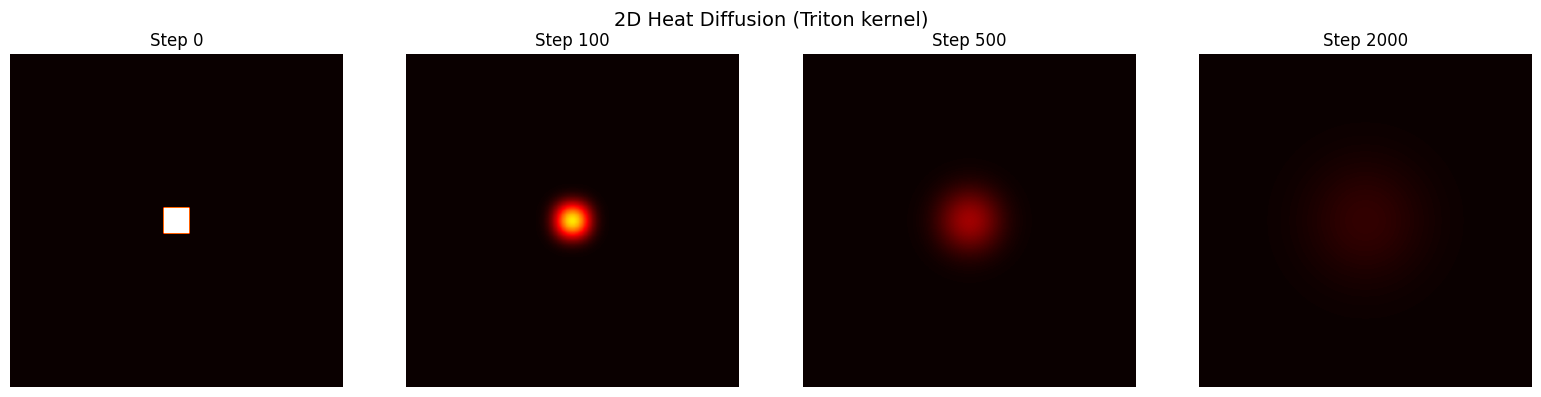

In [7]:
import matplotlib.pyplot as plt

N = 256
u = torch.zeros(N, N, device=DEVICE, dtype=torch.float32)
# Hot spot in the center
u[N//2 - 10 : N//2 + 10, N//2 - 10 : N//2 + 10] = 100.0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
steps = [0, 100, 500, 2000]
step_idx = 0

for t in range(max(steps) + 1):
    if t in steps:
        ax = axes[step_idx]
        ax.imshow(u.cpu().numpy(), cmap='hot', vmin=0, vmax=100)
        ax.set_title(f'Step {t}')
        ax.axis('off')
        step_idx += 1
    u = heat_step_triton(u, alpha=0.25)

plt.suptitle('2D Heat Diffusion (Triton kernel)', fontsize=14)
plt.tight_layout()
plt.show()

## Benchmark

We benchmark the three implementations as a function of grid size (square grids from 256x256 to 4096x4096).

The metric is **GB/s** (effective memory bandwidth). For each step, we read the full grid
and write the full grid, so the effective data moved is `2 * H * W * 4` bytes (float32).

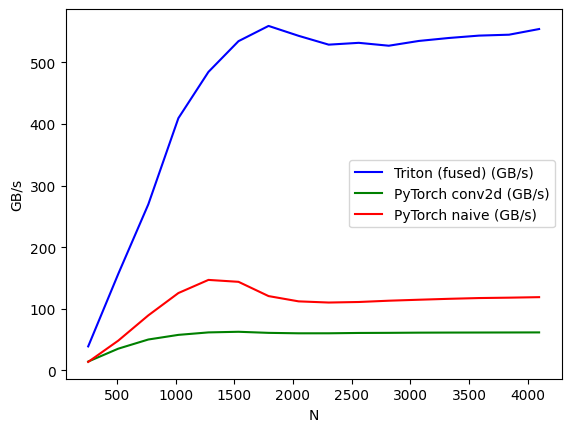

heat-diffusion-performance:
         N  Triton (fused) (GB/s)  PyTorch conv2d (GB/s)  PyTorch naive (GB/s)
0    256.0              39.020056              14.411852             13.814107
1    512.0             156.714970              35.325998             48.367996
2    768.0             269.691762              50.209861             89.393260
3   1024.0             409.560247              57.731706            125.638586
4   1280.0             484.679923              61.740583            146.978948
5   1536.0             534.614503              62.758223            143.868177
6   1792.0             559.356627              61.000481            120.703446
7   2048.0             543.278467              60.283368            112.140912
8   2304.0             528.948708              60.311652            110.236930
9   2560.0             531.895201              60.850510            111.112990
10  2816.0             527.217964              61.026186            113.204307
11  3072.0             5

In [8]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[256 * i for i in range(1, 17)],  # 256 to 4096
        line_arg='provider',
        line_vals=['triton', 'conv2d', 'naive'],
        line_names=['Triton (fused)', 'PyTorch conv2d', 'PyTorch naive'],
        styles=[('blue', '-'), ('green', '-'), ('red', '-')],
        ylabel='GB/s',
        plot_name='heat-diffusion-performance',
        args={},
    )
)
def benchmark(N, provider):
    u = torch.randn(N, N, device=DEVICE, dtype=torch.float32)
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)

    if provider == 'naive':
        ms = triton.testing.do_bench(lambda: heat_step_naive(u))
    elif provider == 'conv2d':
        ms = triton.testing.do_bench(lambda: heat_step_conv2d(u))
    elif provider == 'triton':
        ms = triton.testing.do_bench(lambda: heat_step_triton(u))

    # Effective bandwidth: read + write the full grid
    gbps = 2 * N * N * u.element_size() * 1e-9 / (ms * 1e-3)
    return gbps


benchmark.run(show_plots=True, print_data=True)

## Summary

| Implementation | Kernel Launches per Step | Memory Round-trips | Notes |
|---|---|---|---|
| **Naive PyTorch** | ~6 (slicing + arithmetic) | 6 | Each operation is a separate kernel |
| **conv2d** | 2 (conv + add) | 3 | cuDNN fuses the stencil, but the add is separate |
| **Triton (fused)** | 1 | 1 | Load tile + halo, compute, write -- all in SRAM |

### Key Takeaways

1. **Kernel fusion matters for bandwidth-bound ops.** The stencil is simple arithmetic;
   the bottleneck is moving data to/from HBM. Fewer round-trips = faster execution.

2. **2D tiling with halos** is the standard pattern for stencil computations on GPUs.
   Each thread block loads a tile plus its boundary "halo" cells into shared memory.

3. **conv2d is a clever hack** for prototyping stencils, but a custom kernel avoids the
   overhead of general-purpose convolution machinery.

4. **Triton makes GPU stencils accessible.** What would be 100+ lines of CUDA (with
   shared memory management, synchronization barriers, and index arithmetic) is ~40 lines of Triton.